Started

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier


In [ ]:
# ==============================================================
# Bank Fraud Detection – Full ML Pipeline with Visualizations
# ==============================================================
#SMOTE (Synthetic Minority Over-sampling Technique) is a method used to handle imbalanced datasets by generating synthetic samples for the minority class
#rather than simply duplicating existing ones. This helps improve model performance by providing a more balanced distribution between classes during training.
# ------------------- Step 1: Import Libraries -------------------
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

# Imbalanced dataset handling
from imblearn.over_sampling import SMOTE


In [ ]:
# ------------------- Step 2: Define User Inputs -------------------
train_path = "/content/BankA_SWIFT_Training_Dataset_Full.xlsx"
test_path  = "/content/BankA_SWIFT_Test_Dataset.xlsx"
target_col = "IsFraud"


In [ ]:
# ------------------- Step 3: Smart File Reader -------------------
def smart_read(path):
    """Read CSV or Excel files based on extension."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    ext = os.path.splitext(path)[1].lower()
    if ext in [".csv", ".txt"]:
        return pd.read_csv(path)
    elif ext in [".xls", ".xlsx"]:
        return pd.read_excel(path)
    else:
        raise ValueError("Unsupported file format.")


In [ ]:
# ------------------- Step 4: Clean Data -------------------
def clean_data(df):
    """
    Replace inf/-inf with NaN and fill missing values.
    Numeric: median
    Categorical: mode or 'MISSING'
    """
    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "MISSING")
    return df


In [ ]:
# ------------------- Step 5: Feature Engineering -------------------
def preprocess_data(df):
    """Create timestamp, amount, and risk/repeat flag features."""
    df = df.copy()

    # Timestamp features
    time_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
    if time_cols:
        df["timestamp"] = pd.to_datetime(df[time_cols[0]], errors="coerce")
        df["TxnHour"] = df["timestamp"].dt.hour.fillna(-1).astype(int)
        df["TxnDayOfWeek"] = df["timestamp"].dt.dayofweek.fillna(-1).astype(int)

    # Amount handling
    amt_col = next((c for c in df.columns if "amount" in c.lower()), None)
    df["amt_usd"] = pd.to_numeric(df[amt_col], errors="coerce") if amt_col else 0
    df["log_amt"] = np.log1p(df["amt_usd"].fillna(0))

    # Risk & repeat flags
    df["is_high_risk"] = df.get("IsHighRiskCountry", 0)
    df["is_repeat"] = df.get("IsRepeat", 0)

    # Clean NaN / inf values
    df = clean_data(df)
    return df


In [ ]:
# ------------------- Step 6: Identify Numeric & Categorical Features -------------------
def select_num_cat(X):
    """Separate numeric and categorical features."""
    num = X.select_dtypes(include=[np.number]).columns.tolist()
    cat = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    return num, cat

# Convert categorical columns to strings to fix mixed type error
def convert_cat_to_str(df, cat_cols):
    for col in cat_cols:
        df[col] = df[col].astype(str)
    return df


In [ ]:
# ------------------- Step 7: Build Preprocessor -------------------
def build_preprocessor(num, cat):
    """Build pipeline to scale numeric and encode categorical features."""
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    try:
        catg = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])
    except TypeError:
        catg = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
        ])

    return ColumnTransformer([
        ("num", numeric, num),
        ("cat", catg, cat)
    ])


In [ ]:
# ------------------- Step 8: Model Evaluation -------------------
def evaluate_model(model, X_test, y_test):
    """Evaluate and visualize model performance metrics."""
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc_score = roc_auc_score(y_test, proba) if proba is not None else np.nan

    print("\n=== MODEL METRICS ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc_score:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, proba)
        plt.figure(figsize=(6, 4))
        plt.plot(recall, precision, label="Precision-Recall Curve")
        plt.title("Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend()
        plt.show()


In [ ]:
# ------------------- Step 9: Main Pipeline -------------------
def main(train_path, test_path, target_col):
    # Load data
    train_df = smart_read(train_path)
    test_df = smart_read(test_path)
    print("Train shape:", train_df.shape)
    print("Test shape :", test_df.shape)

    # Drop rows with missing target
    train_df = train_df.dropna(subset=[target_col])
    if target_col in test_df.columns:
        test_df = test_df.dropna(subset=[target_col])

    # EDA - Target distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_col, data=train_df)
    plt.title("Target Distribution in Training Set")
    plt.show()

    # EDA - Correlation heatmap
    plt.figure(figsize=(10, 6))
    corr = train_df.select_dtypes(include=[np.number]).corr()
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.show()

    # Preprocess data
    train_df = preprocess_data(train_df)
    test_df  = preprocess_data(test_df)

    # Split features and target
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)
    X_test  = test_df.drop(columns=[target_col], errors="ignore")
    y_test  = test_df[target_col].astype(int) if target_col in test_df.columns else None

    # Identify numeric & categorical features
    num, cat = select_num_cat(X_train)

    # Convert categorical columns to string to avoid OneHotEncoder errors
    X_train = convert_cat_to_str(X_train, cat)
    X_test  = convert_cat_to_str(X_test, cat)

    # Build preprocessor & transform data
    preprocessor = build_preprocessor(num, cat)
    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep  = preprocessor.transform(X_test)

    print("Processed X_train shape:", X_train_prep.shape)
    print("Processed X_test shape :", X_test_prep.shape)

    # Balance the training data using SMOTE
    print("Before SMOTE:", Counter(y_train))
    X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train_prep, y_train)
    print("After SMOTE:", Counter(y_train_bal))

    # Train Random Forest Classifier
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_train_bal, y_train_bal)

    # Feature Importance - numeric features only
    importances = rf.feature_importances_
    imp_series = pd.Series(importances[:len(num)], index=num).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    imp_series.head(10).plot(kind="bar", color="teal")
    plt.title("Top 10 Feature Importances")
    plt.tight_layout()
    plt.show()

    # Evaluate on test data if available
    if y_test is not None:
        evaluate_model(rf, X_test_prep, y_test)
    else:
        print("No test target found — skipping evaluation.")

    print("\nPipeline completed successfully!")

Train shape: (17524, 35)
Test shape : (1000, 35)


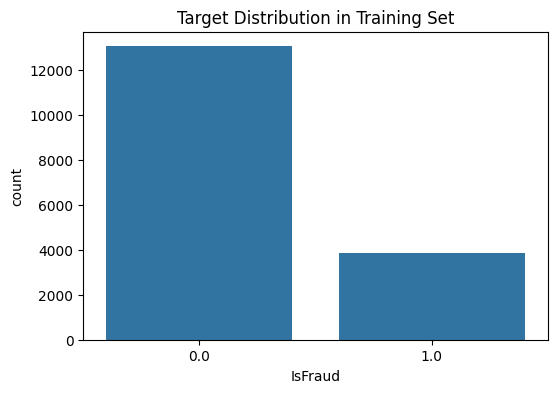

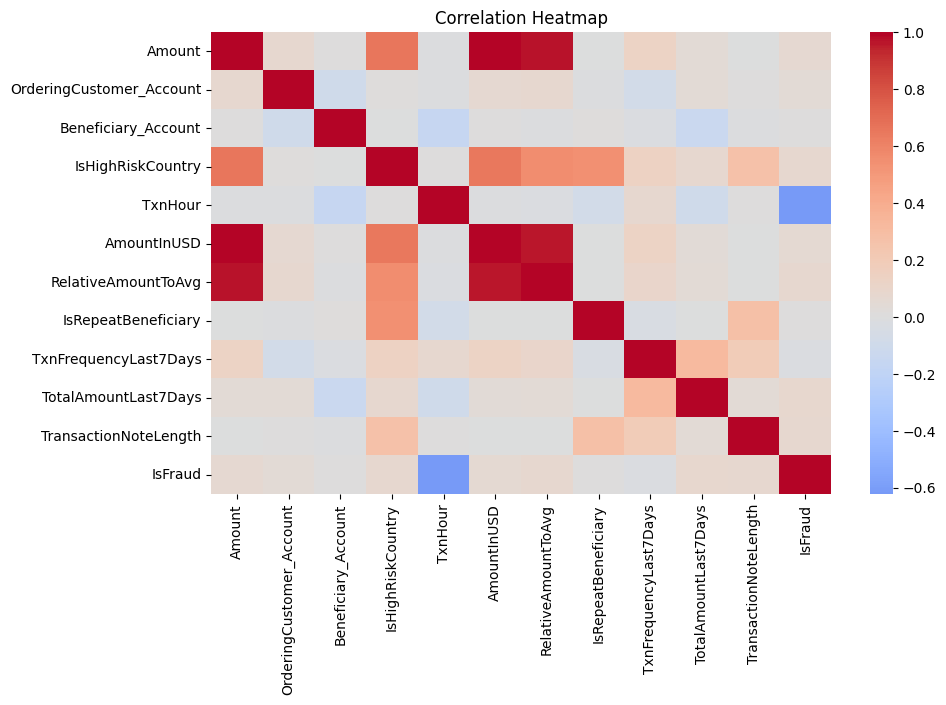

Processed X_train shape: (16875, 1078)
Processed X_test shape : (887, 1078)
Before SMOTE: Counter({0: 13039, 1: 3836})
After SMOTE: Counter({1: 13039, 0: 13039})


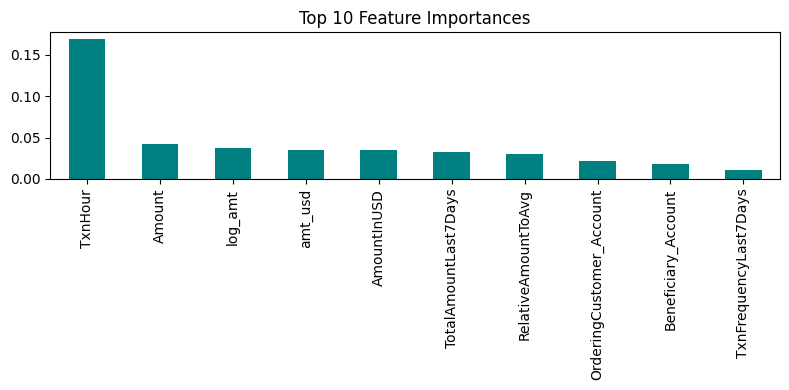


=== MODEL METRICS ===
Accuracy : 0.8365
Precision: 0.7814
Recall   : 0.6796
F1 Score : 0.7269
AUC      : 0.8369

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88       603
           1       0.78      0.68      0.73       284

    accuracy                           0.84       887
   macro avg       0.82      0.80      0.81       887
weighted avg       0.83      0.84      0.83       887



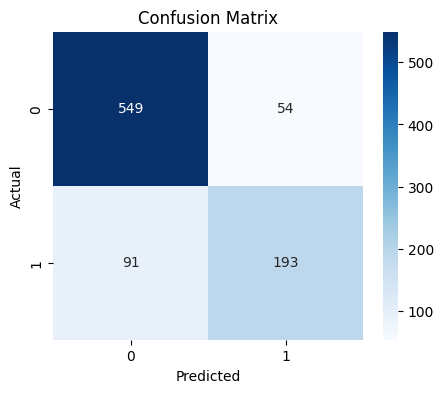

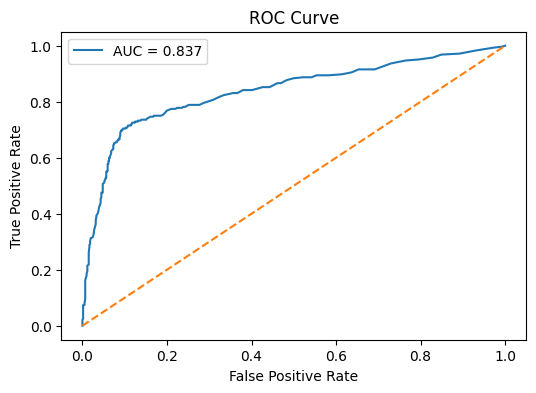

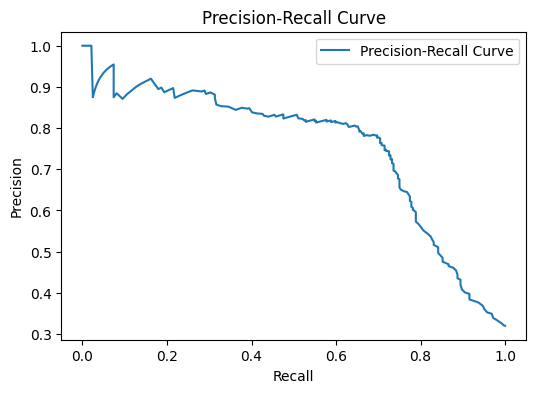


Pipeline completed successfully!


In [ ]:
# ------------------- Step 10: Run the Pipeline -------------------
if __name__ == "__main__":
    main(train_path, test_path, target_col)


